# Insurance Charge Prediction Using Machine Learning

## Problem Statement

Health insurance providers must estimate expected medical charges accurately to manage financial risk and price policies appropriately. Incorrect pricing can lead to underwriting losses or reduced competitiveness in the market.

This project aims to develop and evaluate machine learning models to predict individual medical insurance charges based on demographic and health-related features such as age, BMI, and smoking status. The goal is to compare a baseline linear model with a nonlinear ensemble method to assess predictive performance and interpret feature influence.

## Dataset Overview

The dataset used in this project contains anonymized demographic and health related attributes of insurance beneficiaries. The target variable is:

*   charges - individual medical insurance cost (continuous variable)

Predictor variable considered in this analysis:

*   age - age of the primary beneficiary
*   bmi - body mass index
*   smoker - smoking status (encoded as smoker_yes after dummy transformation)

Categorical variables such as sex and region were converted into numberical format using one hot encoding where appropriate.

The dataset contained no missing values and required minimal cleaning.







In [78]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')
insurance=pd.read_csv('/content/drive/MyDrive/Data Science Projects/insurance.csv')
from google.colab import drive
drive.mount('/content/drive')
insurance.describe()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [79]:
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
insurance.tail()


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [81]:
insurance.shape


(1338, 7)

In [82]:
insurance.dtypes


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [83]:
insurance['region'].value_counts()


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


## Data Preprocessing

In [84]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(["southeast", "southwest", "northwest", "northeast"])
LabelEncoder()

LabelEncoder()

In [85]:
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [86]:
insurance.isna().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [87]:
catColumns = ['sex', 'smoker', 'region']
insurance_dum = pd.get_dummies(insurance, columns = catColumns, drop_first=True)
insurance_dum.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Model Development

In [88]:
X = insurance_dum[['age','bmi', 'smoker_yes']]
y = insurance_dum['charges']
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X,y) # fit linear regression model to training data
linreg.score(X,y) #calculate R-squared score

0.7474771588119513

In [89]:
linreg.score(X,y)*100


74.74771588119513

In [90]:
linreg.coef_


array([  259.54749155,   322.61513282, 23823.68449531])

In [91]:
linreg.intercept_


np.float64(-11676.830425187778)

In [92]:
def calc_insurance(age, bmi, smoker):
  y = ((age*linreg.coef_[0]) + (bmi*linreg.coef_[1]) + (smoker*linreg.coef_[2]) + linreg.intercept_)
  return y
print(calc_insurance(36, 24, 0))


5409.642458337232


In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
linreg.fit(X_train, y_train)

LinearRegression()

In [94]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print("RF Train R²:", rf.score(X_train, y_train))
print("RF Test R²:", rf.score(X_test, y_test))

RF Train R²: 0.9679484794108504
RF Test R²: 0.8346644445453022


## Model Evaluation




In [95]:
# Train and Test Split Results
print("Train and Test Split Results\n")
print("Train R²:", linreg.score(X_train, y_train))
print("Test R²:", linreg.score(X_test, y_test))

# Random Forest Regressor Results
print("\nRandom Forest Regressor Results\n")
print("RF Train R²:", rf.score(X_train, y_train))
print("RF Test R²:", rf.score(X_test, y_test))

Train and Test Split Results

Train R²: 0.7392286795956207
Test R²: 0.7776932310583374

Random Forest Regressor Results

RF Train R²: 0.9679484794108504
RF Test R²: 0.8346644445453022


## Results

Two models were evaluated to predict insurance-related outcomes: Linear Regression and Random Forest. Model was assessed using R2 on both training and testing datasets.



In [96]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Train R²": [linreg.score(X_train, y_train), rf.score(X_train, y_train)],
    "Test R²": [linreg.score(X_test, y_test), rf.score(X_test, y_test)]
})

results

,Model,Train R²,Test R²
0,Linear Regression,0.739229,0.777693
1,Random Forest,0.967948,0.834664


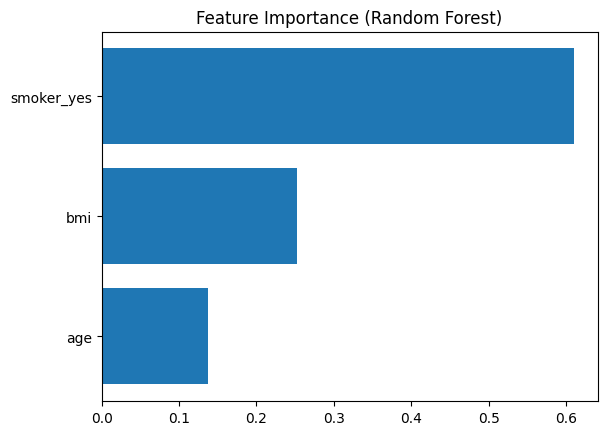

In [97]:
import matplotlib.pyplot as plt
plt.barh(X.columns, rf.feature_importances_)
plt.title("Feature Importance (Random Forest)")
plt.show()

## Model Interpretation

The Random Forest model achieved substantially higher training performance (R² = 0.968) compared to Linear Regression (R² = 0.739), indicating its ability to capture more complex nonlinear relationships in the data.

On the test set, Random Forest also outperformed Linear Regression (0.835 vs 0.778), suggesting improved predictive accuracy. However, the noticeable gap between training and test performance for Random Forest indicates mild overfitting.

Overall, Random Forest demonstrated stronger generalization performance and was selected as the preferred model for prediction.

## Conclusion

This project evaluated two supervised learning models, Linear Regression and Random Forest, to predict insurance-related outcomes. While both models demonstrated reasonable predictive capability, Random Forest achieved stronger overall performance, particularly on the test dataset (R² = o.835). This suggests that nonlinear modeling approaches better capture the complexity of relationships within the data.

Although Random Forest showed some signs of mild overfitting (higher training performance compated to test performance), it generalized more effectively than Linear Regression and was selected as the preferred model.

### Business Impact

From a business perspective, improved prediction accuracy in insurance modeling can directly support more precise risk assessment, pricing strategy, and underwriting decisions. A more accurate model reduces mispricing risk, improves profitability, and enhances competitive positioning. By leveraging machine learning techniques such as Random Forest, insurers can better account for nonlinear interactions among customer and policy attributes that traditional linear models may overlook.

### Future Improvements

Several enhancements could further strengthen this analysis:

*   Perform hyperparameter tuning (e.g., GridSearchCV) to optimize model performance.
*   Apply cross-validation to ensure more stable generalization estimate.
*   Evaluate additional models (e.g., Gradient Boosting, XGBoost).

Overall, this project demonstrates the practical application of machine learning techniques to real world insurance prediction challenges and highlights the value of model comparison, evaluation, and interprestability in data-driven decision-making.



